In [18]:
print("Hello World")

Hello World


In [92]:
import os
import sys
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date, time, timedelta
from meteostat import Point, Daily
import warnings
warnings.filterwarnings("ignore")

#### Core Data Check / Validation

In [42]:
df  = pd.read_excel(r"C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\Twitter_X.xlsx")

In [43]:
df.head(5)

,SL.NO,DATE,SHIFT DUTY,QUERY/REQUEST/COMPLAINT,COMPLAINT DETAILS,COMPLAINT NUMBER,SECTION,SUB-DIVISION,DIVISION,CIRCLE,...,PSCC/FG/TO,REPEAT (Y / N),FORWARDED TO,SENTIMENTS,NATURE OF TWEET,ACTIONABLE/ NON ACTIONABLE,AGEING,SLAB,SLAB2,MINUTE
0,1,2022-06-10,NaN,NaN,Mr. Mohan Maharana complaint regarding the fun...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0
1,2,2022-06-10,NaN,NaN,Mr.Bhawanispanda complaint regarding the repla...,4206102206136,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0
2,3,2022-06-10,NaN,NaN,Mr. Dumb.Orator complaint regarding the unauth...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0
3,4,2022-06-10,NaN,NaN,"Frequent power interuption At- Sihinapada,Masa...",NaN,NaN,NUAPADA,NUAPADA,KALAHANDI,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0
4,5,2022-06-10,NaN,NaN,Mr. akshya_patra tweeted that DTR is in unsafe...,4206102207051,SAINTALA,"SDO-2,TITLAGARH",TITLAGARH,BOLANGIR,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0


In [44]:
# Core Data Check / Validation
print("🔍 Core Data Validation")
print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)

🔍 Core Data Validation
Shape: (31768, 33)
Data Types:
 SL.NO                                      int64
DATE                              datetime64[ns]
SHIFT DUTY                                object
QUERY/REQUEST/COMPLAINT                   object
COMPLAINT DETAILS                         object
COMPLAINT NUMBER                          object
SECTION                                   object
SUB-DIVISION                              object
DIVISION                                  object
CIRCLE                                    object
COMPLAINT TYPE                            object
CONSUMER NUMBER                           object
MOBILE NUMB                               object
DEPT                                      object
CLOSED/OPEN                               object
REMARKS                                   object
TWEET-LINK                                object
COMPLAINANT NAME                          object
COMPLAINT RECEIVED TIME                   object
RESPONSE TIME 

In [45]:
df.isnull().sum()

SL.NO                                 0
DATE                                  0
SHIFT DUTY                        24885
QUERY/REQUEST/COMPLAINT           29356
COMPLAINT DETAILS                     0
COMPLAINT NUMBER                  23848
SECTION                           11185
SUB-DIVISION                       7726
DIVISION                           7362
CIRCLE                             7455
COMPLAINT TYPE                        0
CONSUMER NUMBER                   21956
MOBILE NUMB                       26773
DEPT                                  0
CLOSED/OPEN                           0
REMARKS                              56
TWEET-LINK                            4
COMPLAINANT NAME                    592
COMPLAINT RECEIVED TIME             575
RESPONSE TIME                       629
SECOND RESPONSE TIME              24162
FINAL RESPONSE TIME               20861
FINAL RESPONSE DATE DD/MM/YYYY    20632
PSCC/FG/TO                        27400
REPEAT (Y / N)                    27783


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.columns

Index(['SL.NO', 'DATE', 'SHIFT DUTY', 'QUERY/REQUEST/COMPLAINT',
       'COMPLAINT DETAILS', 'COMPLAINT NUMBER', 'SECTION ', 'SUB-DIVISION',
       'DIVISION', 'CIRCLE', 'COMPLAINT TYPE', 'CONSUMER NUMBER',
       'MOBILE NUMB', 'DEPT', 'CLOSED/OPEN', 'REMARKS', 'TWEET-LINK',
       'COMPLAINANT NAME', 'COMPLAINT RECEIVED TIME', 'RESPONSE TIME',
       'SECOND RESPONSE TIME', 'FINAL RESPONSE TIME',
       'FINAL RESPONSE DATE DD/MM/YYYY', 'PSCC/FG/TO', 'REPEAT (Y / N)',
       'FORWARDED TO', 'SENTIMENTS', 'NATURE OF TWEET',
       'ACTIONABLE/ NON ACTIONABLE', 'AGEING', 'SLAB', 'SLAB2', 'MINUTE'],
      dtype='object')

<Axes: xlabel='DEPT'>

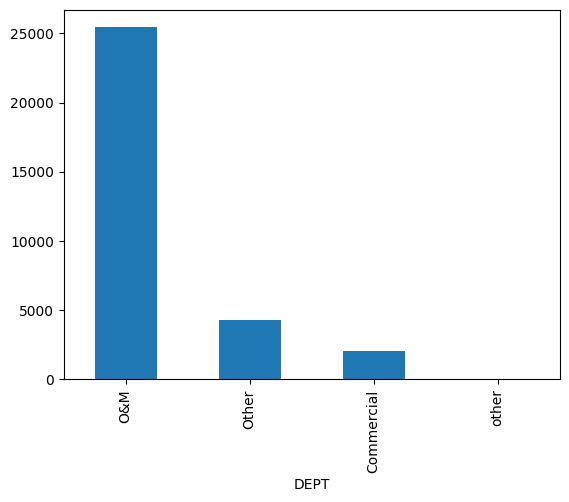

In [48]:
df['DEPT'].value_counts().plot(kind='bar')

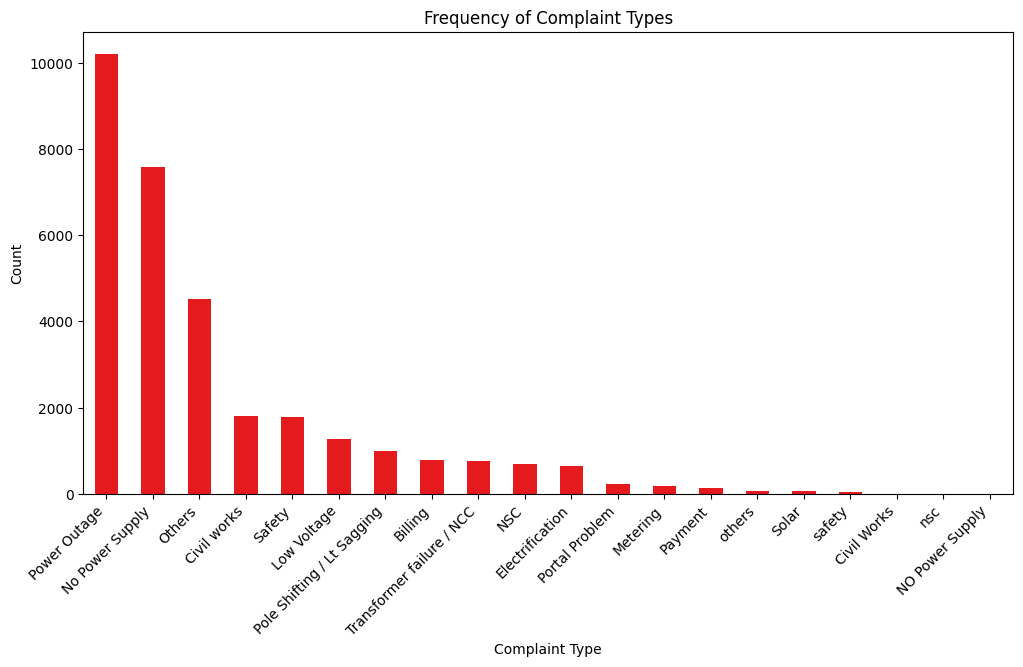

In [66]:
# Use the 'Set1' colormap, which has 9 distinct colors,
# or 'tab10' for 10 colors.
df['COMPLAINT TYPE'].value_counts().plot(
    kind='bar',
    figsize=(12, 6), # Using a good size for better viewing
    cmap='Set1'      # Applies a distinct color to each complaint type
)

# Add clear labels
plt.title('Frequency of Complaint Types')
plt.xlabel('Complaint Type')
plt.ylabel('Count')

# You may need to rotate the x-axis labels if the complaint types are long
plt.xticks(rotation=45, ha='right')

plt.show()

In [50]:
df['COMPLAINT TYPE'].value_counts()

COMPLAINT TYPE
Power Outage                  10206
No Power Supply                7579
Others                         4512
Civil works                    1797
Safety                         1784
Low Voltage                    1274
Pole Shifting / Lt Sagging      995
Billing                         776
Transformer failure / NCC       761
NSC                             700
Electrification                 653
Portal Problem                  223
Metering                        190
Payment                         131
others                           71
Solar                            69
safety                           44
Civil Works                       1
nsc                               1
NO Power Supply                   1
Name: count, dtype: int64

<Axes: xlabel='SHIFT DUTY'>

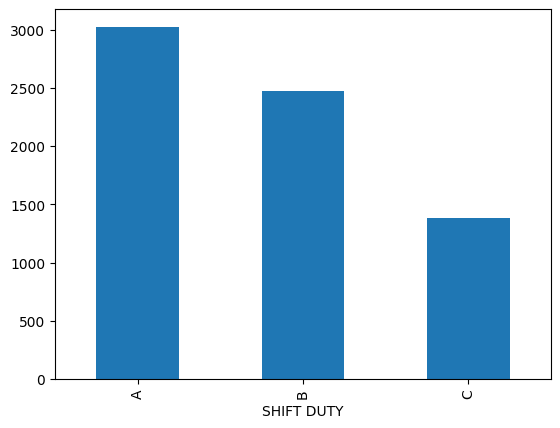

In [52]:
df['SHIFT DUTY'].value_counts().plot(kind='bar')

<Axes: xlabel='QUERY/REQUEST/COMPLAINT'>

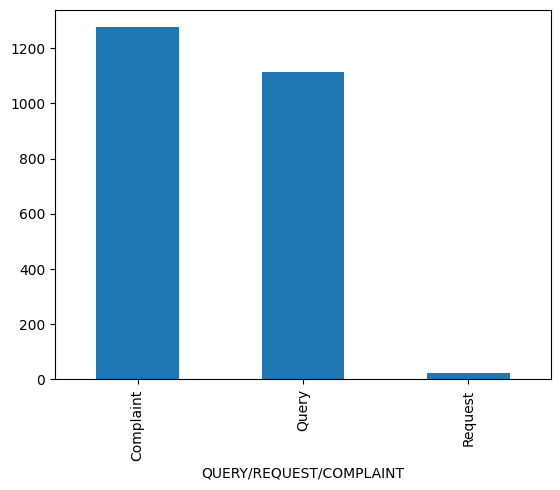

In [53]:
df['QUERY/REQUEST/COMPLAINT'].value_counts().plot(kind='bar')

<Axes: xlabel='CLOSED/OPEN'>

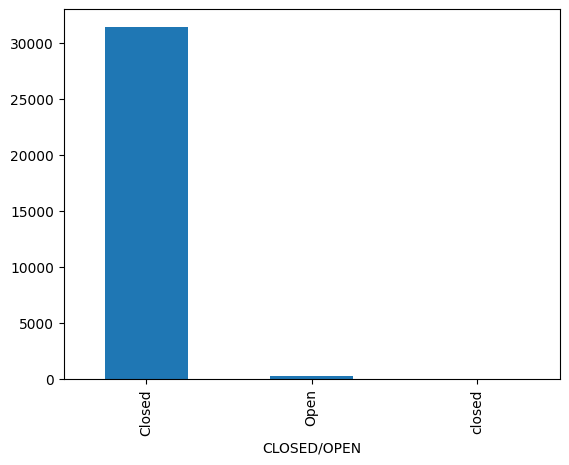

In [60]:

df['CLOSED/OPEN'].value_counts().plot(kind='bar')

<Axes: xlabel='PSCC/FG/TO'>

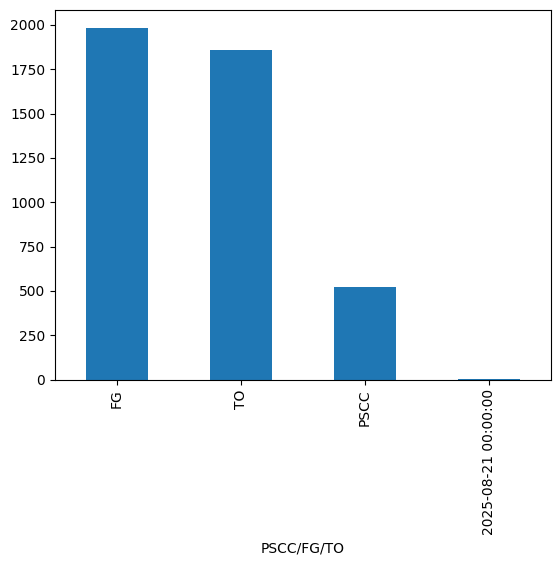

In [61]:
df['PSCC/FG/TO'].value_counts().plot(kind='bar')

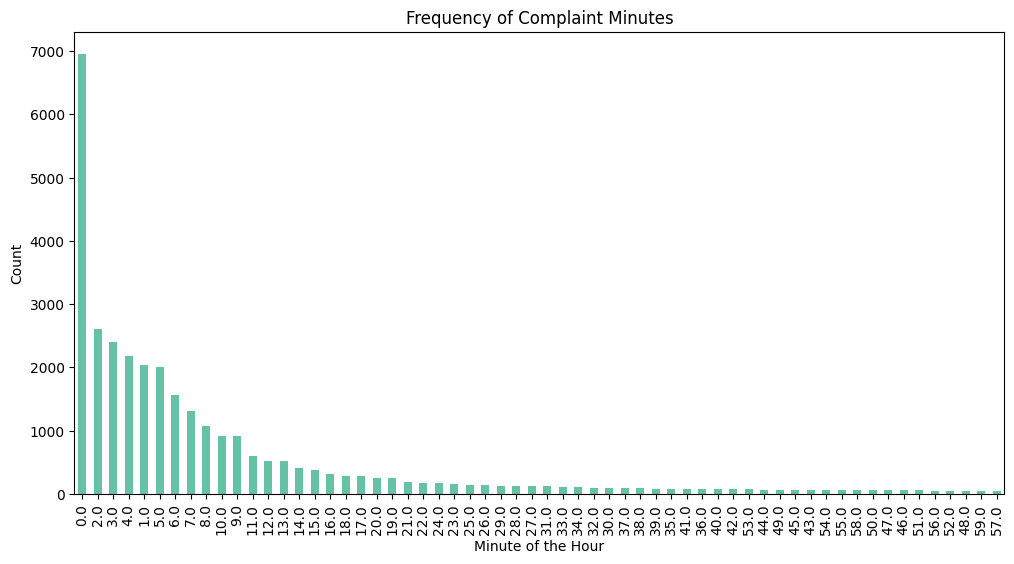

In [65]:
# The 'cmap' parameter is added to automatically apply a color map to the bars.
df['MINUTE'].value_counts().plot(
    kind='bar',
    figsize=(12, 6),
    cmap='Set2'  # Use a distinct color palette
)

plt.title('Frequency of Complaint Minutes')
plt.xlabel('Minute of the Hour')
plt.ylabel('Count')

# Display the plot
plt.show()

<Axes: xlabel='SLAB2'>

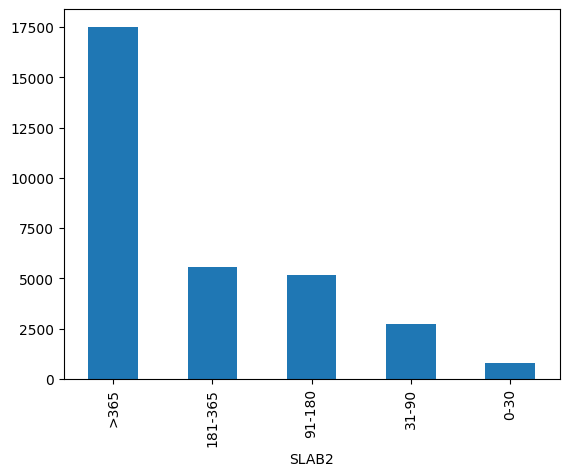

In [63]:
df['SLAB2'].value_counts().plot(kind='bar')

In [82]:
day_and_count = pd.to_datetime(df['DATE'])

In [84]:
day_and_count.info()

<class 'pandas.core.series.Series'>
RangeIndex: 31768 entries, 0 to 31767
Series name: DATE
Non-Null Count  Dtype         
--------------  -----         
31768 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 248.3 KB


In [85]:
# Group the data by date and count the occurrences
daily_counts = df.groupby('DATE').size().reset_index(name='COUNT')

In [89]:
daily_counts.head(3)

,DATE,COUNT
0,2022-06-10,10
1,2022-06-11,12
2,2022-06-12,5


In [90]:
daily_counts.tail(3)

,DATE,COUNT
1239,2025-11-01,26
1240,2025-11-02,27
1241,2025-11-03,23


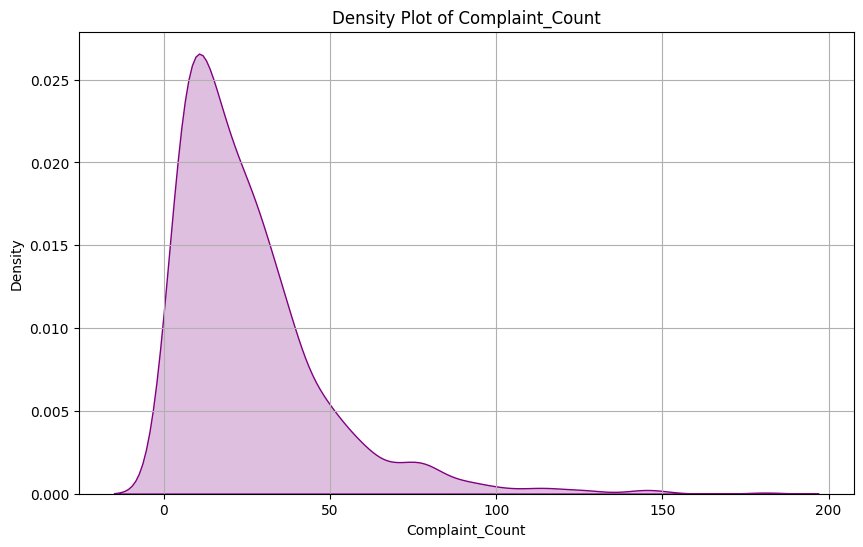

In [88]:
plt.figure(figsize=(10, 6))
sns.kdeplot(daily_counts['COUNT'], shade=True, color='purple')
plt.title('Density Plot of Complaint_Count')
plt.xlabel('Complaint_Count')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [94]:
daily_counts.shape

(1242, 2)

In [93]:
# Define the geographical coordinates and date range
latitude = 21.4669
longitude = 83.9812
start_date = datetime(2022, 6, 10)
end_date = datetime(2025, 11, 3)

# Create a Point object for the location
location = Point(latitude, longitude)

# Fetch the daily weather data
# This connects to the Meteostat API to get the data
daily_data = Daily(location, start_date, end_date)
data_frame = daily_data.fetch()

# Print the resulting DataFrame
print(data_frame)


            tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt    pres  tsun
time                                                                    
2022-06-10  35.5  30.9  41.4   0.0  <NA>  <NA>   9.2  <NA>   999.5  <NA>
2022-06-11  34.6  28.1  41.6   3.3  <NA>  <NA>  11.5  <NA>  1000.8  <NA>
2022-06-12  35.4  28.3  42.2   0.1  <NA>  <NA>   7.6  <NA>  1001.5  <NA>
2022-06-13  34.5  30.0  41.8   0.0  <NA>  <NA>   7.1  <NA>  1003.0  <NA>
2022-06-14  34.6  30.9  43.0   0.0  <NA>  <NA>   7.1  <NA>  1002.1  <NA>
...          ...   ...   ...   ...   ...   ...   ...   ...     ...   ...
2025-10-30  27.2  24.9  31.3   6.2  <NA>  <NA>  14.6  <NA>  1008.5  <NA>
2025-10-31  27.4  25.0  31.0   1.2  <NA>  <NA>  12.3  <NA>  1009.0  <NA>
2025-11-01  27.8  24.8  31.4   0.2  <NA>  <NA>   9.6  <NA>  1009.3  <NA>
2025-11-02  27.2  23.7  30.8   0.0  <NA>  <NA>   6.4  <NA>  1009.7  <NA>
2025-11-03  26.4  22.8  30.9   0.0  <NA>  <NA>   8.8  <NA>  1009.8  <NA>

[1243 rows x 10 columns]


In [95]:
data_frame

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
time,,,,,,,,,,
2022-06-10,35.5,30.9,41.4,0.0,<NA>,<NA>,9.2,<NA>,999.5,<NA>
2022-06-11,34.6,28.1,41.6,3.3,<NA>,<NA>,11.5,<NA>,1000.8,<NA>
2022-06-12,35.4,28.3,42.2,0.1,<NA>,<NA>,7.6,<NA>,1001.5,<NA>
2022-06-13,34.5,30.0,41.8,0.0,<NA>,<NA>,7.1,<NA>,1003.0,<NA>
2022-06-14,34.6,30.9,43.0,0.0,<NA>,<NA>,7.1,<NA>,1002.1,<NA>
...,...,...,...,...,...,...,...,...,...,...
2025-10-30,27.2,24.9,31.3,6.2,<NA>,<NA>,14.6,<NA>,1008.5,<NA>
2025-10-31,27.4,25.0,31.0,1.2,<NA>,<NA>,12.3,<NA>,1009.0,<NA>
2025-11-01,27.8,24.8,31.4,0.2,<NA>,<NA>,9.6,<NA>,1009.3,<NA>


In [100]:
import requests
import pandas as pd

# ---------------------------
# Location and Date Range
# ---------------------------
latitude = 21.4669
longitude = 83.9812
start_date = "2022-06-10"
end_date   = "2025-11-03"

# ---------------------------
# Build API URL (only daily mean temperature & humidity)
# ---------------------------
url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}&longitude={longitude}"
    f"&start_date={start_date}&end_date={end_date}"
    f"&daily=temperature_2m_mean,relative_humidity_2m_mean"
    f"&timezone=Asia%2FKolkata"
)

print("Fetching data from:")
print(url)

# ---------------------------
# Fetch Data
# ---------------------------
response = requests.get(url)
response.raise_for_status()
data = response.json()

# ---------------------------
# Convert to DataFrame
# ---------------------------
temperature_humidity = pd.DataFrame(data["daily"])

# Convert date to datetime and set as index
temperature_humidity["time"] = pd.to_datetime(temperature_humidity["time"])

# ---------------------------
# Rename Columns for Clarity
# ---------------------------
temperature_humidity.rename(columns={
    "temperature_2m_mean": "day_temperature_C",
    "relative_humidity_2m_mean": "day_humidity_percent"
}, inplace=True)

# ---------------------------
# Display and Save
# ---------------------------
print(temperature_humidity.head())



Fetching data from:
https://archive-api.open-meteo.com/v1/archive?latitude=21.4669&longitude=83.9812&start_date=2022-06-10&end_date=2025-11-03&daily=temperature_2m_mean,relative_humidity_2m_mean&timezone=Asia%2FKolkata
        time  day_temperature_C  day_humidity_percent
0 2022-06-10               34.6                    47
1 2022-06-11               34.8                    42
2 2022-06-12               34.4                    45
3 2022-06-13               34.7                    45
4 2022-06-14               32.9                    52


In [102]:
temperature_humidity

,time,day_temperature_C,day_humidity_percent
0,2022-06-10,34.6,47
1,2022-06-11,34.8,42
2,2022-06-12,34.4,45
3,2022-06-13,34.7,45
4,2022-06-14,32.9,52
...,...,...,...
1238,2025-10-30,26.6,83
1239,2025-10-31,26.4,85
1240,2025-11-01,26.8,84
1241,2025-11-02,26.5,79


In [ ]:
import requests
import pandas as pd
from datetime import date, timedelta

# ---------------------------
# Location (Sambalpur)
# ---------------------------
latitude = 21.4669
longitude = 83.9812

# ---------------------------
# Date Range: Today → Next 60 Days
# ---------------------------
start_date = date.today().strftime("%Y-%m-%d")
end_date = (date.today() + timedelta(days=60)).strftime("%Y-%m-%d")

# ---------------------------
# Build Forecast API URL
# ---------------------------
url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}&longitude={longitude}"
    f"&start_date={start_date}&end_date={end_date}"
    f"&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean"
    f"&timezone=Asia%2FKolkata"
)

print("Fetching forecast data from:")
print(url)

# ---------------------------
# Fetch Data
# ---------------------------
response = requests.get(url)
response.raise_for_status()
data = response.json()

# ---------------------------
# Convert to DataFrame
# ---------------------------
forecast_df = pd.DataFrame(data["daily"])

# Convert date
forecast_df["date"] = pd.to_datetime(forecast_df["time"])
forecast_df.drop(columns=["time"], inplace=True)

# ---------------------------
# Rename Columns
# ---------------------------
forecast_df.rename(columns={
    "temperature_2m_mean": "forecast_temperature_C",
    "relative_humidity_2m_mean": "forecast_humidity_percent"
}, inplace=True)

# Keep only required features (date, temp, humidity)
forecast_df = forecast_df[["date", "forecast_temperature_C", "forecast_humidity_percent"]]

# ---------------------------
# Display and Save
# ---------------------------
print(forecast_df.head())

In [ ]:
import requests
import pandas as pd
from datetime import date, timedelta

# ---------------------------
# Location (Sambalpur)
# ---------------------------
latitude = 21.4669
longitude = 83.9812

# ---------------------------
# Date Range: Today → Next 60 Days
# ---------------------------
start_date = date.today().strftime("%Y-%m-%d")
end_date = (date.today() + timedelta(days=60)).strftime("%Y-%m-%d")

# ---------------------------
# Build Forecast API URL
# ---------------------------
url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}&longitude={longitude}"
    f"&start_date={start_date}&end_date={end_date}"
    f"&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean"
    f"&timezone=Asia/Kolkata"
)

print("Fetching forecast data from:")
print(url)

# ---------------------------
# Fetch Data
# ---------------------------
response = requests.get(url)
response.raise_for_status()
data = response.json()

# ---------------------------
# Convert to DataFrame
# ---------------------------
forecast_df = pd.DataFrame(data["daily"])

# Convert date
forecast_df["date"] = pd.to_datetime(forecast_df["time"])
forecast_df.drop(columns=["time"], inplace=True)

# ---------------------------
# Rename Columns
# ---------------------------
forecast_df.rename(columns={
    "temperature_2m_mean": "forecast_temperature_C",
    "relative_humidity_2m_mean": "forecast_humidity_percent"
}, inplace=True)

# Keep only required features (date, temp, humidity)
forecast_df = forecast_df[["date", "forecast_temperature_C", "forecast_humidity_percent"]]

# ---------------------------
# Display and Save
# ---------------------------
print(forecast_df.head())